In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split,KFold,cross_val_score,GridSearchCV
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv(r"C:\Users\MOHIT JHA\Desktop\Projects\House Price\boston.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

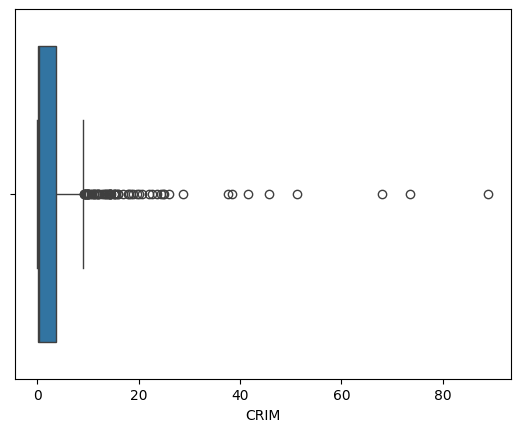

In [8]:
sns.boxplot(x=df['CRIM'])
plt.show()

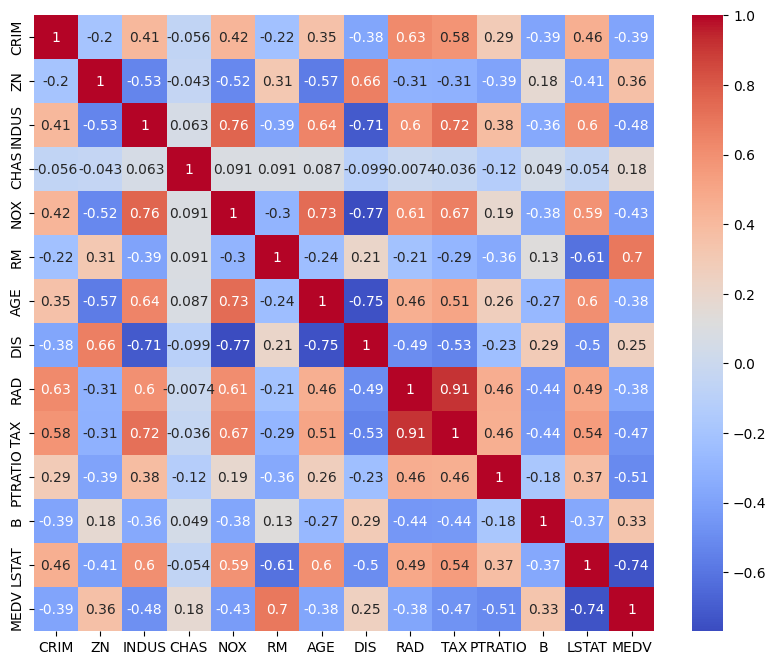

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [11]:
X = df.drop("MEDV",axis=1)
y = df["MEDV"]

In [12]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

In [14]:
kf = KFold(n_splits=5,shuffle=True,random_state=42)

In [15]:
for name,model in models.items():
    scores = cross_val_score(model,X_train,y_train,cv=kf,scoring="r2")
    print(f"{name} R2 Score:", scores.mean())

Linear R2 Score: 0.7184784187192006
Ridge R2 Score: 0.717298487899872
Lasso R2 Score: 0.6709761191055615


In [16]:
ridge_params = {"alpha":[0.1,1,10,100]}

ridge_grid = GridSearchCV(Ridge(),ridge_params,cv=5,scoring="r2")
ridge_grid.fit(X_train,y_train)

print("Best Ridge",ridge_grid.best_params_)

Best Ridge {'alpha': 0.1}


In [17]:
lasso_params = {"alpha":[0.01,0.1,1,10]}

lasso_grid = GridSearchCV(Lasso(),lasso_params,cv=5,scoring="r2")
lasso_grid.fit(X_train,y_train)

print("Best Lasso:",lasso_grid.best_params_)

Best Lasso: {'alpha': 0.01}


In [18]:
best_model = ridge_grid.best_estimator_
y_pred = best_model.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 Score: 0.6686244122021412
RMSE: 4.929607033039524
